# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [42]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import os
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [43]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv(dataset_file).drop(columns=["customerID"])
data["gender"] = data["gender"].map({"Male": 1, "Female": 0})

new_val = []
for i, val in enumerate(data["TotalCharges"]):
    try:
        new_val.append(float(val))
    except Exception:
        new_val.append(float("nan"))
data["TotalCharges"] = new_val
        
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in yes_no_cols:
    data[col] = data[col].map({"Yes": 1, "No": 0})
    
display(data.info())

print("Columns with missing values:")
nan_count = data.isna().sum()
print(nan_count.loc[nan_count > 0])

Path to dataset files: /home/zico/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15

None

Columns with missing values:
TotalCharges    11
dtype: int64


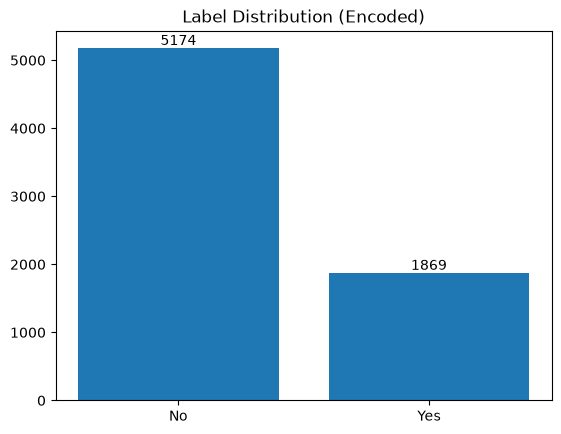

In [44]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_count = data["Churn"].value_counts()
plt.bar(target_count.keys(), target_count.values, 0.8)
for key, val in target_count.items():
    plt.text(key, val+50, str(val), ha="center")

plt.xticks([0, 1], labels=["No", "Yes"])
plt.title("Label Distribution (Encoded)")
plt.show()

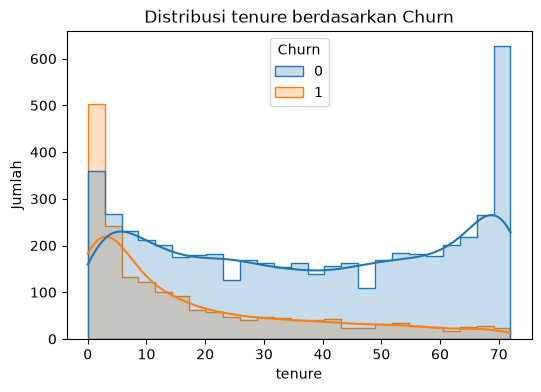

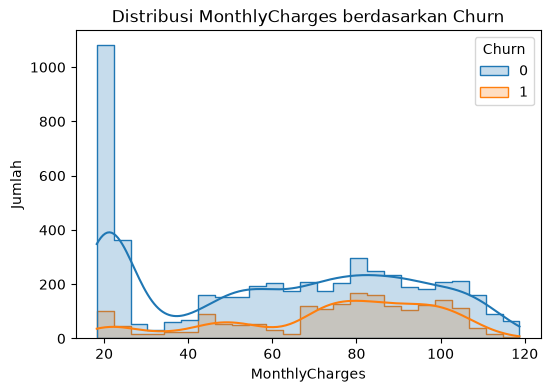

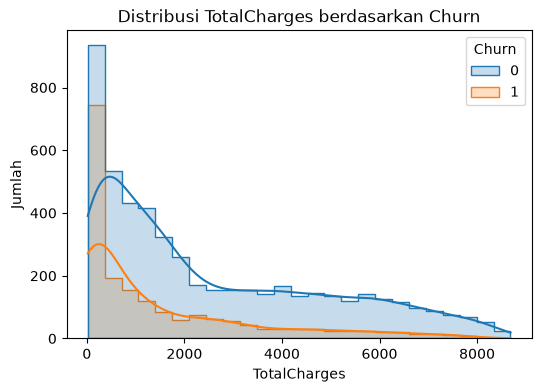

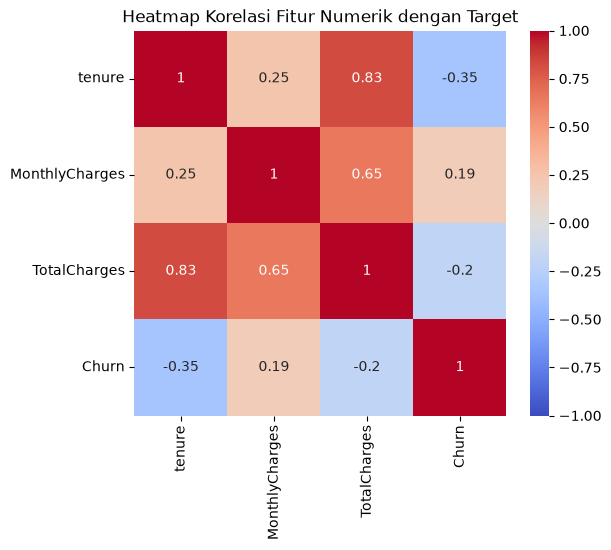

In [45]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=data,
        x=col,
        hue="Churn",
        bins=25,
        kde=True,
        element="step",
        common_norm=False,
    )
    plt.title(f"Distribusi {col} berdasarkan Churn")
    plt.xlabel(col)
    plt.ylabel("Jumlah")
    plt.show()

corr = data[num_cols + ["Churn"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap Korelasi Fitur Numerik dengan Target")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [46]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
print("Jumlah missing value setelah preprocessing:", data.isna().sum().sum())

Jumlah missing value setelah preprocessing: 0


In [48]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category", "str"]).columns, drop_first=False)
print("Jumlah fitur setelah encoding:", X.shape[1])

Jumlah fitur setelah encoding: 40


In [49]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Ukuran train set:", X_train.shape)
print("Ukuran test set:", X_test.shape)

Ukuran train set: (5634, 40)
Ukuran test set: (1409, 40)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [50]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [51]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
baseline_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=500,
    random_state=42,
)
baseline_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [52]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
baseline_pred = baseline_model.predict(X_test_scaled)
print("Baseline accuracy:", accuracy_score(y_test, baseline_pred))

Baseline accuracy: 0.7955997161107168


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [53]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activation_results = []
for activation in ["relu", "tanh", "logistic"]:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=activation,
        max_iter=500,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    activation_results.append({
        "activation": activation,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1_score": f1_score(y_test, test_pred, zero_division=0),
    })

In [74]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
activation_df = pd.DataFrame(activation_results)
display(activation_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True))

,activation,train_accuracy,test_accuracy,precision,recall,f1_score
0,relu,0.817181,0.795600,0.648276,0.502674,0.566265
1,logistic,0.825169,0.786373,0.619672,0.505348,0.556701
2,tanh,0.823394,0.782825,0.604294,0.526738,0.562857


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [75]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
hidden_layer_options = [(i,) for i in range(1, 21)]
architecture_results = []
for activation in ["relu", "tanh", "logistic"]:
    for hidden_layer in hidden_layer_options:
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer,
            activation=activation,
            max_iter=1000,
            random_state=42, 
        )
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
        architecture_results.append({
            "activation": activation,
            "hidden_layer_sizes": hidden_layer,
            "train_accuracy": accuracy_score(y_train, train_pred),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "f1_score": f1_score(y_test, test_pred, zero_division=0),
        })

In [76]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
architecture_df = pd.DataFrame(architecture_results)
display(architecture_df.sort_values(["activation", "hidden_layer_sizes"]).reset_index(drop=True))

,activation,hidden_layer_sizes,train_accuracy,test_accuracy,f1_score
0,logistic,"(1,)",0.801207,0.797019,0.610354
1,logistic,"(2,)",0.804224,0.789922,0.585434
2,logistic,"(3,)",0.807242,0.789212,0.578723
3,logistic,"(4,)",0.808839,0.795600,0.587393
4,logistic,"(5,)",0.811324,0.797019,0.585507
5,logistic,"(6,)",0.813809,0.794180,0.576023
6,logistic,"(7,)",0.814874,0.790632,0.573082
7,logistic,"(8,)",0.814874,0.792761,0.578035
8,logistic,"(9,)",0.822506,0.779986,0.552023
9,logistic,"(10,)",0.825169,0.786373,0.556701


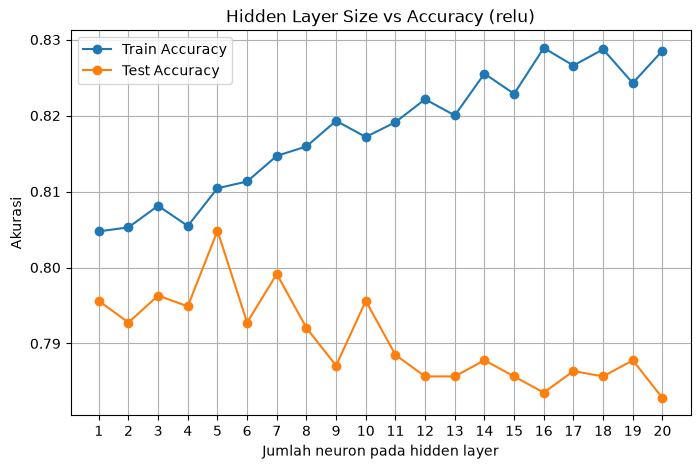

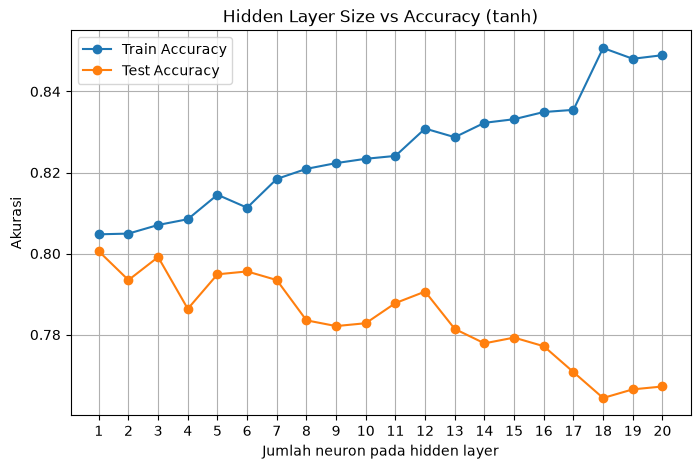

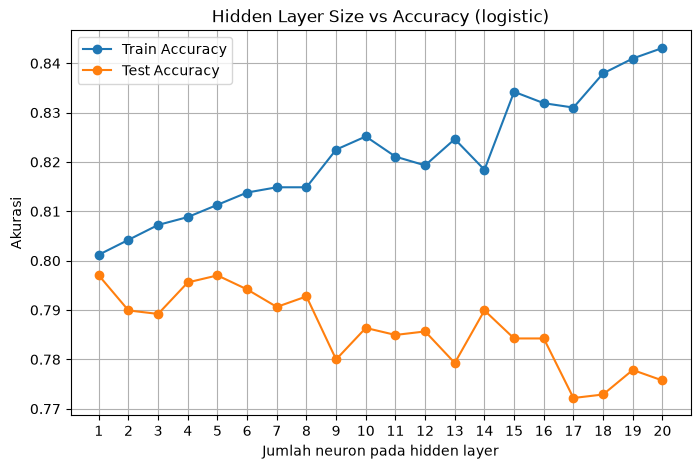

In [77]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
for activation in ["relu", "tanh", "logistic"]:
    subset = architecture_df[architecture_df["activation"] == activation].copy()
    subset["hidden_size"] = subset["hidden_layer_sizes"].apply(lambda x: x[0])
    subset = subset.sort_values("hidden_size")

    plt.figure(figsize=(8, 5))
    plt.plot(subset["hidden_size"], subset["train_accuracy"], marker="o", label="Train Accuracy")
    plt.plot(subset["hidden_size"], subset["test_accuracy"], marker="o", label="Test Accuracy")
    plt.xticks(subset["hidden_size"])
    plt.xlabel("Jumlah neuron pada hidden layer")
    plt.ylabel("Akurasi")
    plt.title(f"Hidden Layer Size vs Accuracy ({activation})")
    plt.legend()
    plt.grid(True)
    plt.show()

# 4. Evaluasi Model

In [78]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
comparison_rows = []
for activation in ["relu", "tanh", "logistic"]:
    row = architecture_df[architecture_df["activation"] == activation].sort_values("test_accuracy", ascending=False).iloc[0]
    model = MLPClassifier(
        hidden_layer_sizes=row["hidden_layer_sizes"],
        activation=row["activation"],
        max_iter=500,
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    comparison_rows.append({
        "activation": row["activation"],
        "hidden_layer_sizes": row["hidden_layer_sizes"],
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0),
    })

best_model_overview = pd.DataFrame(comparison_rows)
display(best_model_overview.sort_values("accuracy", ascending=False).reset_index(drop=True))

,activation,hidden_layer_sizes,accuracy,precision,recall,f1_score
0,relu,"(5,)",0.804826,0.663366,0.537433,0.593796
1,tanh,"(1,)",0.800568,0.637168,0.577540,0.605891
2,logistic,"(1,)",0.797019,0.622222,0.598930,0.610354


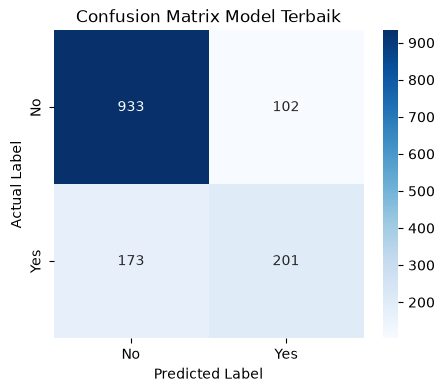

In [79]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_row = architecture_df.sort_values("test_accuracy", ascending=False).iloc[0]
best_model = MLPClassifier(
    hidden_layer_sizes=best_row["hidden_layer_sizes"],
    activation=best_row["activation"],
    max_iter=500,
    random_state=42,
)
best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Model Terbaik")
plt.show()

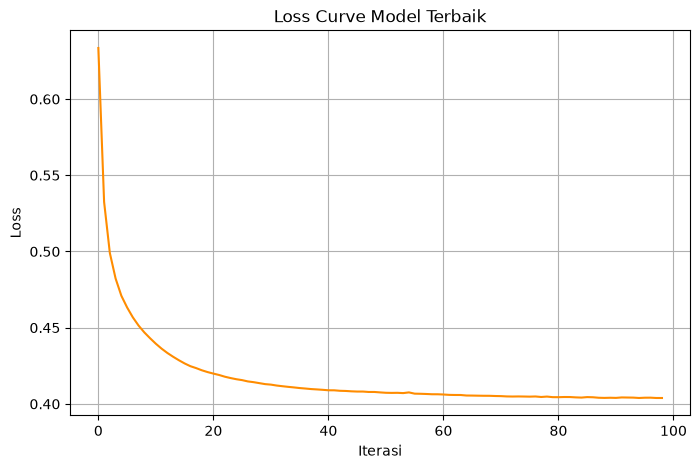

In [80]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(8, 5))
plt.plot(best_model.loss_curve_, color="darkorange")
plt.title("Loss Curve Model Terbaik")
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.
Pada hasil eksperimen, didapatkan bahwa aktivasi ReLU memberikan test accuracy tertinggi dengan margin yang cukup tipis. Salah satu penyebab yang mungkin adalah ReLU tidak membatasi nilainya pada rentang [0, 1] atau [-1, 1] sehingga risiko vanishing gradients dapat dihindari.

Pada grafik yang ada di cell sebelumnya, ketiga fungsi aktivasi memiliki pola yang berbeda. Model dengan aktivasi ReLU mulai menunjukkan gejala overfitting ketika jumlah neuron pada hidden layer lebih besar dari lima. Model dengan aktivasi sigmoid mulai menunjukkan gejala overfitting ketika jumlah neuron pada hidden layer lebih dari lima. Model dengan aktivasi tanh mulai menunjukkan gejala overfitting ketika jumlah neuron pada hidden layer lebih dari satu. Gejala dapat diobservasi dengan melihat tren antara kedua loss. Overfitting terjadi ketika training accuracy naik, tetapi test accuracy menurun.

Pada grafik loss curve di atas, model sudah menunjukkan konvergensi ketika jumlah iterasi mendekati 100. Apabila loss belum konvergen, training bisa diteruskan atau dihentikan bergantung dengan tujuan dan tren test loss/accuracy.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Kesimpulan: MLP sangat robust untuk data yang memiliki dimensi besar dan jumlah yang banyak, tetapi hasil masih dipengaruhi oleh konfigurasi hyperparameter yang tepat dan teknik regularisasi yang sesuai.

Saran: GridSearch